# Trail Data Analysis (MOD Error Calculation)

This notebook analyzes the accuracy of user drawings compared to target trails.

**Input Files:**
- `PathData_*.csv`: Recorded user strokes.
- `TrailDefinitions.json`: Ground truth definitions exported from Unity.

**Metrics:**
- **MOD (Mean Orthogonal Distance / Mean Euclidean Distance)**: For each recorded point, finding the closest point on the ideal trajectory and averaging that distance.

In [40]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# Constants
DATA_FILE = 'PathData_2025-12-09_23-33-44.csv' # Replace with your dynamic file name if needed
DEFS_FILE = 'TrailDefinitions.json'


## 1. Load Data

We load the trail definitions to understand the ideal shapes and the recorded CSV data.

In [41]:
# Load Definitions
with open(DEFS_FILE, 'r') as f:
    defs_json = json.load(f)

trace_defs = {}
for item in defs_json['definitions']:
    t_id = item['typeId']
    trace_defs[t_id] = item

print(f"Loaded {len(trace_defs)} definitions.")

# Load Recorded Data
df = pd.read_csv(DATA_FILE)
print(f"Loaded {len(df)} data points.")
df.head()

Loaded 6 definitions.
Loaded 8997 data points.


,Timestamp,Position_X,Position_Y,Position_Z,Rotation_X,Rotation_Y,Rotation_Z,IsTargetTrace,StrokeID,TargetID,TrailTypeID
0,0.000000,-0.049674,0.020284,-0.209228,78.23649,346.7054,246.7307,True,1,0,5
1,0.003784,-0.049675,0.020288,-0.209255,78.22677,346.7874,246.8262,True,1,0,5
2,0.006683,-0.049771,0.020319,-0.209240,78.20318,346.7397,246.8668,True,1,0,5
3,0.009350,-0.049775,0.020324,-0.209260,78.19483,346.8033,246.9436,True,1,0,5
4,0.011616,-0.049779,0.020330,-0.209279,78.18700,346.8626,247.0151,True,1,0,5


## 2. Ideal Path Reconstruction

We replicate the Unity C# `GetPointOnPath(t)` logic in Python to generate dense point clouds for the ground truth curves. This allows us to find the "closest point" for error calculation.

In [42]:
def vector3_from_dict(d):
    return np.array([d['x'], d['y'], d['z']])

def generate_ideal_path(def_item, num_points=1000):
    """
    Generates points for the target trail based on definition.
    Matches Unity's TargetTrail.GetPointOnPath()
    """
    start = vector3_from_dict(def_item['startPosition'])
    end = vector3_from_dict(def_item['endPosition'])
    
    shape = def_item['shape']
    amp_start = def_item['amplitudeStart']
    amp_end = def_item['amplitudeEnd']
    periods = def_item['periods']
    
    t_values = np.linspace(0, 1, num_points)
    points = []
    
    # Precompute Baseline Basis
    baseline = end - start
    baseline_len = np.linalg.norm(baseline)
    baseline_dir = baseline / baseline_len if baseline_len > 0 else np.array([0,1,0])
    
    # Calculate WaveUp Vector (Perpendicular logic from C#)
    # Vector3 waveUp = Vector3.Cross(baselineDir, Vector3.forward).normalized;
    # Unity Forward is (0,0,1)
    forward = np.array([0, 0, 1])
    wave_up = np.cross(baseline_dir, forward)
    norm_up = np.linalg.norm(wave_up)
    
    if norm_up < 0.001:
        wave_up = np.array([0, 1, 0]) # Fallback Up
    else:
        wave_up = wave_up / norm_up
        
    for t in t_values:
        # Linear Interpolation for Baseline
        straight_pos = start + (end - start) * t
        
        if shape == "Straight":
            points.append(straight_pos)
        else: # SineWave
            # Amplitude Lerp
            current_amp = amp_start + (amp_end - amp_start) * t
            # Sine Value
            sine_val = np.sin(t * periods * np.pi * 2.0)
            
            pos = straight_pos + wave_up * current_amp * sine_val
            points.append(pos)
            
    return np.array(points)

# Generate Ideal Paths for all types and store in KDTrees for fast lookup
ideal_trees = {}
ideal_points_cache = {}

for t_id, item in trace_defs.items():
    pts = generate_ideal_path(item, num_points=2000) # High res for accuracy
    ideal_points_cache[t_id] = pts
    ideal_trees[t_id] = KDTree(pts)

## 3. Calculate Error (MOD)

We obtain the MOD error by processing the DataFrame via the `TrailTypeID` column.

In [43]:
results = []

# Ensure data is sorted by StrokeID and Timestamp
df = df.sort_values(by=['StrokeID', 'Timestamp'])

# Group by Unique Stroke (TargetID distinguishes instances in a sequence)
# We group by StrokeID AND TargetID to be safe
grouped = df.groupby(['StrokeID', 'TargetID', 'TrailTypeID'])

for (stroke_id, target_id, trail_type_id), group in grouped:
    if trail_type_id not in ideal_trees:
        continue
        
    # Get Sample Points
    samples = group[['Position_X', 'Position_Y', 'Position_Z']].values
    
    # Find Distance to Closest Point on Ideal Curve
    tree = ideal_trees[trail_type_id]
    distances, _ = tree.query(samples)
    
    # Metrics
    mean_error = np.mean(distances)
    max_error = np.max(distances)
    std_dev = np.std(distances)
    
    results.append({
        'StrokeID': stroke_id,
        'TargetID': target_id,
        'TrailTypeID': trail_type_id,
        'Shape': trace_defs[trail_type_id]['shape'],
        'MOD_Error': mean_error,
        'Max_Error': max_error,
        'Std_Dev': std_dev,
        'Sample_Count': len(samples)
    })

results_df = pd.DataFrame(results)

# Display Summary
print("Average Error by Shape:")
print(results_df.groupby('Shape')['MOD_Error'].mean())

results_df

Average Error by Shape:
Shape
SineWave    0.010289
Straight    0.010720
Name: MOD_Error, dtype: float64


,StrokeID,TargetID,TrailTypeID,Shape,MOD_Error,Max_Error,Std_Dev,Sample_Count
0,1,0,5,Straight,0.007536,0.020649,0.004973,911
1,9,1,4,Straight,0.028297,0.064063,0.014479,1406
2,10,2,3,Straight,0.005691,0.009628,0.002033,326
3,16,3,2,Straight,0.004242,0.007132,0.001444,400
4,18,4,5,Straight,0.007836,0.011519,0.002085,602
5,21,5,0,SineWave,0.009861,0.021935,0.004876,2739
6,23,6,0,SineWave,0.010718,0.024492,0.005445,2613


## 4. Visualization

Visualizing a specific stroke with Error Lines.
**NOTE:** We swap axes to match Unity Coordinates (Y-Up).
- Plot X = Unity X
- Plot Y = Unity Z (Depth/Forward)
- Plot Z = Unity Y (Up)

**Correction:** Forced cubic axis limits for correct scaling.

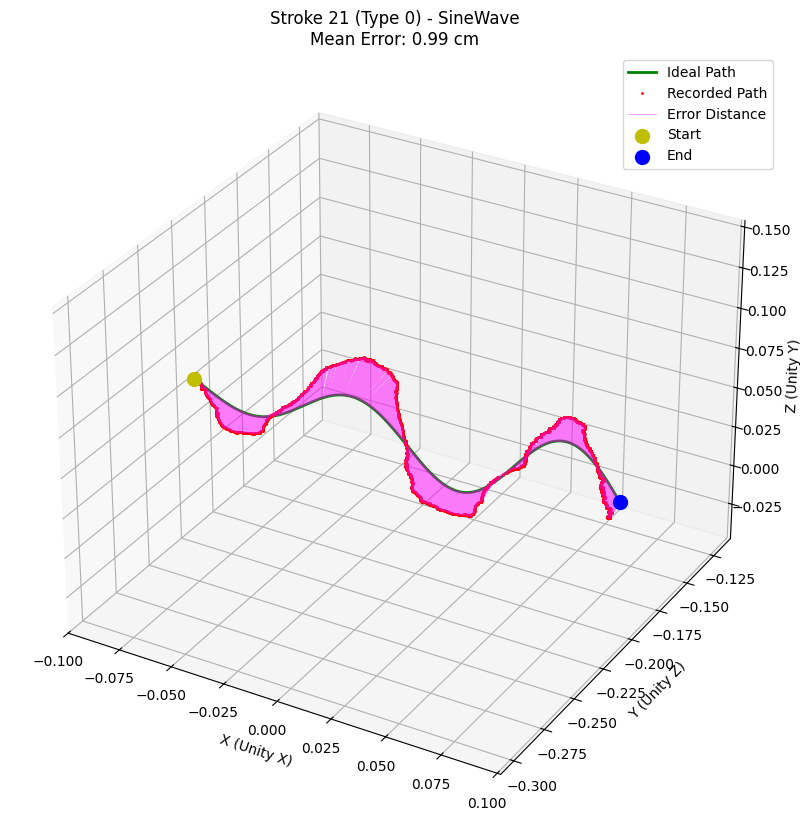

In [44]:
def plot_stroke(stroke_id, target_id):
    subset = df[(df['StrokeID'] == stroke_id) & (df['TargetID'] == target_id)]
    if subset.empty:
        print("Stroke not found.")
        return
    
    t_id = subset.iloc[0]['TrailTypeID']
    
    # Ideal Path
    ideal = ideal_points_cache[t_id]
    
    # Recorded Path (Unity Normals)
    recorded = subset[['Position_X', 'Position_Y', 'Position_Z']].values
    
    # 1. Calculate Closest Points on Ideal
    tree = ideal_trees[t_id]
    distances, indices = tree.query(recorded)
    closest_points = ideal[indices]
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # UNITY COORDINATE MAPPING for Visualization
    # Unity: Y is Up, Z is Forward
    # Matplotlib: Z is usually height.
    # Mapping: MatPlot_X = Unity_X, MatPlot_Y = Unity_Z, MatPlot_Z = Unity_Y
    
    # Data Maps
    ix, iy, iz = ideal[:,0], ideal[:,2], ideal[:,1]
    rx, ry, rz = recorded[:,0], recorded[:,2], recorded[:,1]
    cx, cy, cz = closest_points[:,0], closest_points[:,2], closest_points[:,1]
    
    # Plot Ideal
    ax.plot(ix, iy, iz, 'g-', label='Ideal Path', linewidth=2)
    
    # Plot Recorded
    ax.plot(rx, ry, rz, 'r.', label='Recorded Path', markersize=2)
    
    # Plot Error Lines (Connecting Recorded -> Closest Ideal)
    # Format for single plot command: P1, P2, None, P3, P4, None ...
    # Using numpy braiding for speed
    nan_spacer = np.full(len(rx), np.nan)
    
    # X Coords
    err_x = np.array([rx, cx, nan_spacer]).T.flatten()
    # Y Coords (Unity Z)
    err_y = np.array([ry, cy, nan_spacer]).T.flatten()
    # Z Coords (Unity Y)
    err_z = np.array([rz, cz, nan_spacer]).T.flatten()
    
    ax.plot(err_x, err_y, err_z, color='magenta', linewidth=0.5, alpha=0.5, label='Error Distance')

    # Markers
    ax.scatter(ix[0], iy[0], iz[0], c='y', s=100, label='Start')
    ax.scatter(ix[-1], iy[-1], iz[-1], c='b', s=100, label='End')
    
    ax.set_title(f"Stroke {stroke_id} (Type {t_id}) - {trace_defs[t_id]['shape']}\nMean Error: {np.mean(distances)*100:.2f} cm")
    ax.set_xlabel('X (Unity X)')
    ax.set_ylabel('Y (Unity Z)')
    ax.set_zlabel('Z (Unity Y)')
    
    # --- ENFORCE EQUAL ASPECT RATIO ---
    all_x = np.concatenate([ix, rx])
    all_y = np.concatenate([iy, ry])
    all_z = np.concatenate([iz, rz])
    
    max_range = np.array([np.ptp(all_x), np.ptp(all_y), np.ptp(all_z)]).max() / 2.0
    mid_x = (np.max(all_x) + np.min(all_x)) * 0.5
    mid_y = (np.max(all_y) + np.min(all_y)) * 0.5
    mid_z = (np.max(all_z) + np.min(all_z)) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    ax.legend()
    plt.show()

# Plot the first stroke
if not results_df.empty:
    # Find a SineWave to plot if available
    sine_strokes = results_df[results_df['Shape'] == 'SineWave']
    if not sine_strokes.empty:
        first_stroke = sine_strokes.iloc[0]
    else:
        first_stroke = results_df.iloc[0]
        
    plot_stroke(first_stroke['StrokeID'], first_stroke['TargetID'])